In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
df = pd.read_csv("../data/uav_fault_dataset_v1.csv")

In [3]:
df.dtypes

bag                object
timestamp_ns        int64
roll_cmd          float64
roll_meas         float64
roll_error        float64
pitch_cmd         float64
pitch_meas        float64
pitch_error       float64
yaw_cmd           float64
yaw_meas          float64
yaw_error         float64
vel_x             float64
vel_y             float64
vel_z             float64
imu_x             float64
imu_y             float64
imu_z             float64
engine_fault        int64
aileron_fault       int64
elevator_fault      int64
rudder_fault        int64
ground_speed      float64
binary_fault        int64
dtype: object

# Data Overview

In [4]:
print(df.shape)
print(df.info())

(180812, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180812 entries, 0 to 180811
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   bag             180812 non-null  object 
 1   timestamp_ns    180812 non-null  int64  
 2   roll_cmd        180812 non-null  float64
 3   roll_meas       180812 non-null  float64
 4   roll_error      180812 non-null  float64
 5   pitch_cmd       180812 non-null  float64
 6   pitch_meas      180812 non-null  float64
 7   pitch_error     180812 non-null  float64
 8   yaw_cmd         180812 non-null  float64
 9   yaw_meas        180812 non-null  float64
 10  yaw_error       180812 non-null  float64
 11  vel_x           180812 non-null  float64
 12  vel_y           180812 non-null  float64
 13  vel_z           180812 non-null  float64
 14  imu_x           180812 non-null  float64
 15  imu_y           180812 non-null  float64
 16  imu_z           180812 non-null  float64
 1

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print(missing)

missing_percent = (missing / len(df) * 100).round(2)
print(missing_percent)

Series([], dtype: int64)
Series([], dtype: float64)


# Duplicate Rows

In [6]:
print("duplicated row : ",df.duplicated().sum())


duplicated row :  0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,180812.0,1.536186e+18,2.552247e+15,1.531931e+18,1.532987e+18,1.536692e+18,1.538765e+18,1.539876e+18
roll_cmd,180812.0,1.085774e-01,2.213079e+01,-4.500000e+01,-2.150250e+01,-9.999999e-02,9.700000e+00,4.499000e+01
roll_meas,180812.0,5.609018e+00,1.767877e+01,-6.645238e+01,-1.070823e+00,1.802363e+00,9.861669e+00,7.128139e+01
roll_error,180812.0,-5.500441e+00,1.441541e+01,-1.062053e+02,-1.728321e+01,-2.406277e+00,2.745284e+00,9.828865e+01
pitch_cmd,180812.0,-6.179695e-01,5.301747e+00,-2.499000e+01,-2.620000e+00,0.000000e+00,1.030000e+00,2.000000e+01
pitch_meas,180812.0,5.292030e-01,6.004527e+00,-5.688078e+01,-1.096565e+00,5.454269e-01,2.054308e+00,7.293653e+01
pitch_error,180812.0,-1.147173e+00,6.450553e+00,-9.304937e+01,-3.104228e+00,-5.996998e-01,1.073058e+00,5.941078e+01
yaw_cmd,180812.0,1.095005e+01,1.038293e+02,-1.790000e+02,-8.200000e+01,0.000000e+00,1.130000e+02,1.800000e+02
yaw_meas,180812.0,-4.744680e+01,9.914901e+01,-1.799952e+02,-1.238708e+02,-8.398824e+01,2.515860e+01,1.799866e+02
yaw_error,180812.0,5.839685e+01,1.326115e+02,-3.587891e+02,-5.047535e+00,1.907950e+01,1.137684e+02,3.589952e+02


# Fault Distribution

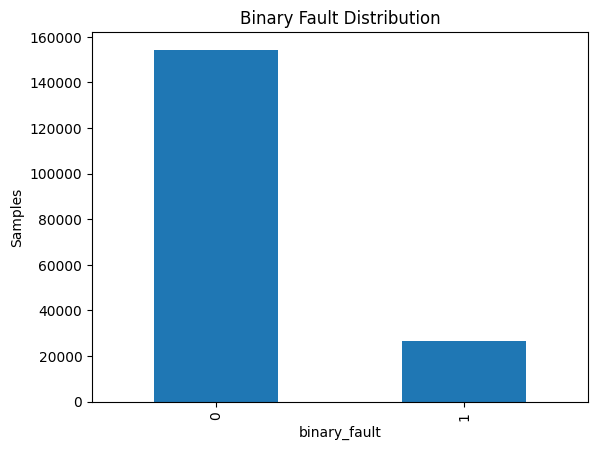

In [7]:
df["binary_fault"].value_counts().plot(kind="bar")

plt.title("Binary Fault Distribution")
plt.ylabel("Samples")
plt.show()

In [8]:
df.head(4)

,bag,timestamp_ns,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,pitch_error,yaw_cmd,yaw_meas,...,vel_z,imu_x,imu_y,imu_z,engine_fault,aileron_fault,elevator_fault,rudder_fault,ground_speed,binary_fault
0,carbonZ_2018-07-18-12-10-11.bag,1531930511391720552,0.100000,2.954323,-2.854323,-2.55,8.487809,-11.037809,0.0,-86.14962,...,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0
1,carbonZ_2018-07-18-12-10-11.bag,1531930511452938696,30.340000,2.954323,27.385678,-1.31,8.487809,-9.797809,88.0,-86.14962,...,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0
2,carbonZ_2018-07-18-12-10-11.bag,1531930511484229416,30.320000,2.954323,27.365677,-1.31,8.487809,-9.797809,88.0,-86.14962,...,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0,20.401346,0
3,carbonZ_2018-07-18-12-10-11.bag,1531930511543160328,30.299999,2.954323,27.345677,-1.31,8.487809,-9.797809,88.0,-86.14962,...,4.326915,-0.0748,-0.023208,-0.996428,0,0,0,0,20.059080,0


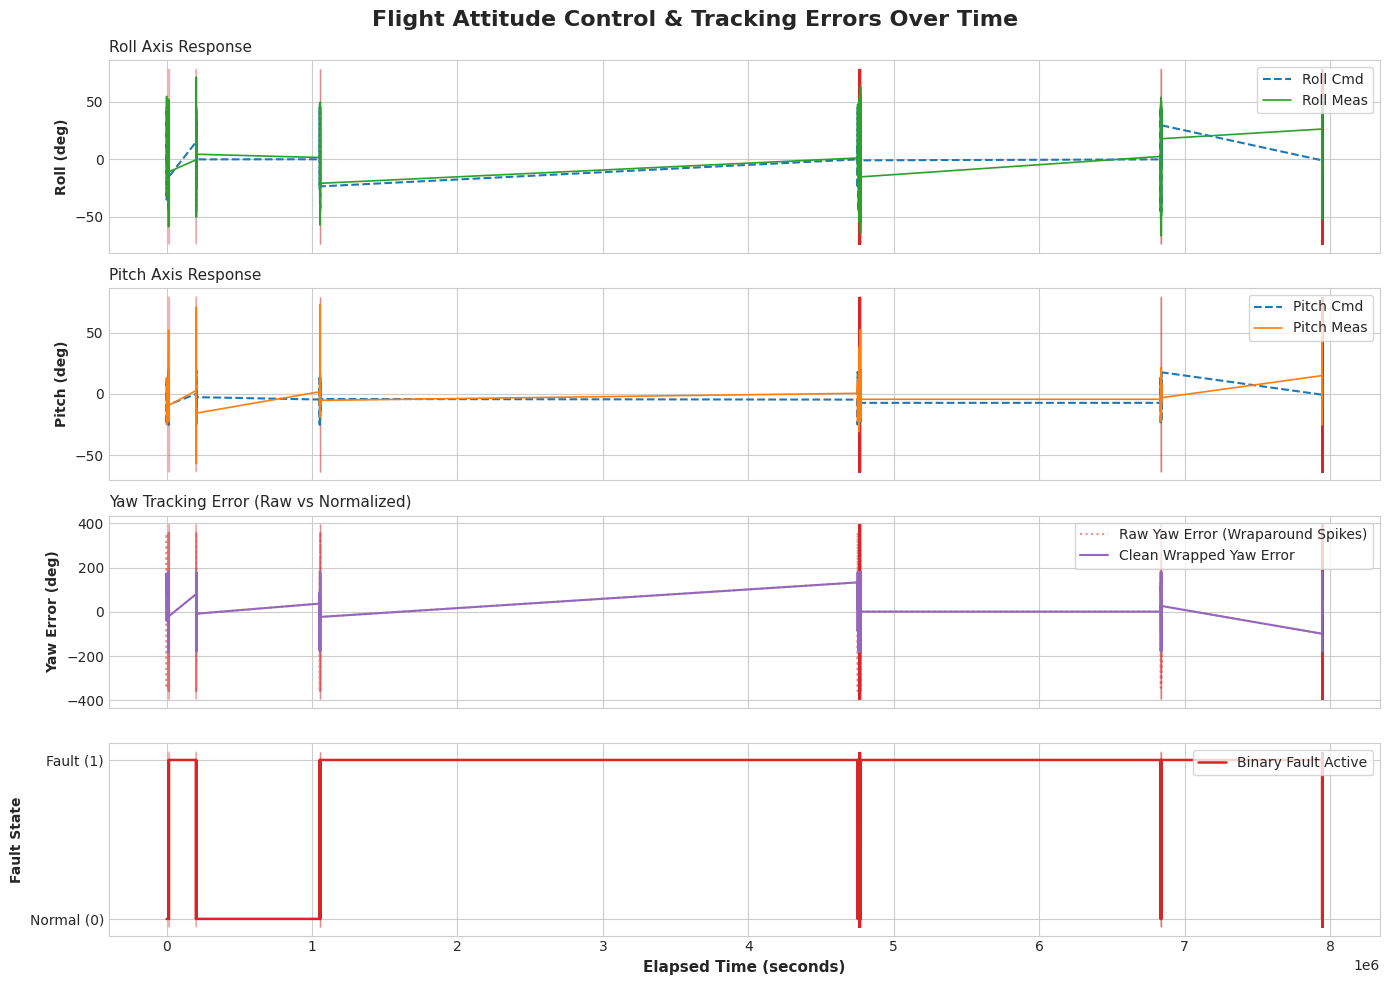

In [31]:

# Set Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# 1. Load Data & Preprocess Angles
# df = pd.read_csv("your_flight_data.csv")

# Ensure elapsed time in seconds (starting from t=0)
df['time_sec'] = (df['timestamp_ns'] - df['timestamp_ns'].min()) / 1e9
df = df.sort_values('timestamp_ns').reset_index(drop=True)

# ==============================================================================
# FIGURE 1: Time-Series Tracking & Fault Regions
# ==============================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Flight Attitude Control & Tracking Errors Over Time', fontsize=16, fontweight='bold', y=0.98)

# Highlight fault regions across all subplots
fault_mask = df['binary_fault'] == 1
fault_blocks = (fault_mask != fault_mask.shift()).cumsum()

# Roll Axis
axes[0].plot(df['time_sec'], df['roll_cmd'], label='Roll Cmd', color='#1f77b4', linewidth=1.5, linestyle='--')
axes[0].plot(df['time_sec'], df['roll_meas'], label='Roll Meas', color='#2ca02c', linewidth=1.2)
axes[0].set_ylabel('Roll (deg)', fontweight='bold')
axes[0].legend(loc='upper right', frameon=True)
axes[0].set_title('Roll Axis Response', fontsize=11, loc='left')

# Pitch Axis
axes[1].plot(df['time_sec'], df['pitch_cmd'], label='Pitch Cmd', color='#1f77b4', linewidth=1.5, linestyle='--')
axes[1].plot(df['time_sec'], df['pitch_meas'], label='Pitch Meas', color='#ff7f0e', linewidth=1.2)
axes[1].set_ylabel('Pitch (deg)', fontweight='bold')
axes[1].legend(loc='upper right', frameon=True)
axes[1].set_title('Pitch Axis Response', fontsize=11, loc='left')

# Yaw Axis & Wraparound Correction Comparison
axes[2].plot(df['time_sec'], df['yaw_error'], label='Raw Yaw Error (Wraparound Spikes)', color='#d62728', alpha=0.5, linestyle=':')
axes[2].plot(df['time_sec'], df['yaw_error_clean'], label='Clean Wrapped Yaw Error', color='#9467bd', linewidth=1.5)
axes[2].set_ylabel('Yaw Error (deg)', fontweight='bold')
axes[2].legend(loc='upper right', frameon=True)
axes[2].set_title('Yaw Tracking Error (Raw vs Normalized)', fontsize=11, loc='left')

# Fault Status Bar
axes[3].step(df['time_sec'], df['binary_fault'], where='post', color='#d62728', linewidth=1.8, label='Binary Fault Active')
axes[3].set_ylabel('Fault State', fontweight='bold')
axes[3].set_yticks([0, 1])
axes[3].set_yticklabels(['Normal (0)', 'Fault (1)'])
axes[3].set_xlabel('Elapsed Time (seconds)', fontweight='bold', fontsize=11)
axes[3].legend(loc='upper right', frameon=True)

# Add shaded red overlay on all subplots wherever binary_fault == 1
for ax in axes:
    ax.fill_between(df['time_sec'], ax.get_ylim()[0], ax.get_ylim()[1], 
                    where=fault_mask, color='#d62728', alpha=0.15, label='Fault Period' if ax == axes[0] else "")

plt.tight_layout()
plt.show()

In [30]:
# # 1. Sort by nanoseconds first
# df = df.sort_values('timestamp_ns').reset_index(drop=True)

# # 2. Plot bag by bag (so separate flights don't connect across gaps)
# for bag_name, group in df.groupby('bag'):
#     # Convert timestamp to relative seconds for THIS bag
#     group['rel_time_sec'] = (group['timestamp_ns'] - group['timestamp_ns'].min()) / 1e9
    
#     plt.figure(figsize=(12, 3))
#     plt.step(group['rel_time_sec'], group['binary_fault'], where='post', color='red')
#     plt.title(f"Fault State - {bag_name}")
#     plt.xlabel("Flight Time (seconds)")
#     plt.ylabel("Fault (0 or 1)")
#     plt.show()

In [18]:
# Count of rows vs total time spent in each state
print(df['binary_fault'].value_counts())
# See if 'Elapsed Time' is accumulated across multiple bag files
print(df['bag'].nunique())

binary_fault
0    154350
1     26462
Name: count, dtype: int64
36


In [22]:
bag_status = (
    df.groupby("bag")["binary_fault"]
      .max()
      .map({0: "Normal", 1: "Fault"})
)

print(bag_status.value_counts())

print("Unique bags:", df["bag"].nunique())

binary_fault
Fault     29
Normal     7
Name: count, dtype: int64
Unique bags: 36


In [23]:
bag_summary = df.groupby("bag").agg(
    total_points=("binary_fault", "size"),
    fault_points=("binary_fault", "sum")
)

bag_summary["fault_percentage"] = (
    bag_summary["fault_points"] /
    bag_summary["total_points"] * 100
)

bag_summary.sort_values("fault_percentage", ascending=False)

,total_points,fault_points,fault_percentage
bag,,,
carbonZ_2018-09-11-14-41-38.bag,6115,5150,84.219133
carbonZ_2018-09-11-14-52-54.bag,5185,2684,51.764706
carbonZ_2018-07-30-16-39-00.bag,11076,4764,43.011918
carbonZ_2018-10-05-14-37-22.bag,6499,1844,28.373596
carbonZ_2018-07-18-15-53-31.bag,7760,1900,24.484536
carbonZ_2018-10-05-15-55-10.bag,2749,647,23.535831
carbonZ_2018-09-11-17-27-13.bag,5721,1216,21.255025
carbonZ_2018-07-30-17-46-31.bag,2385,401,16.813417
carbonZ_2018-09-11-17-55-30.bag,6283,1026,16.329779


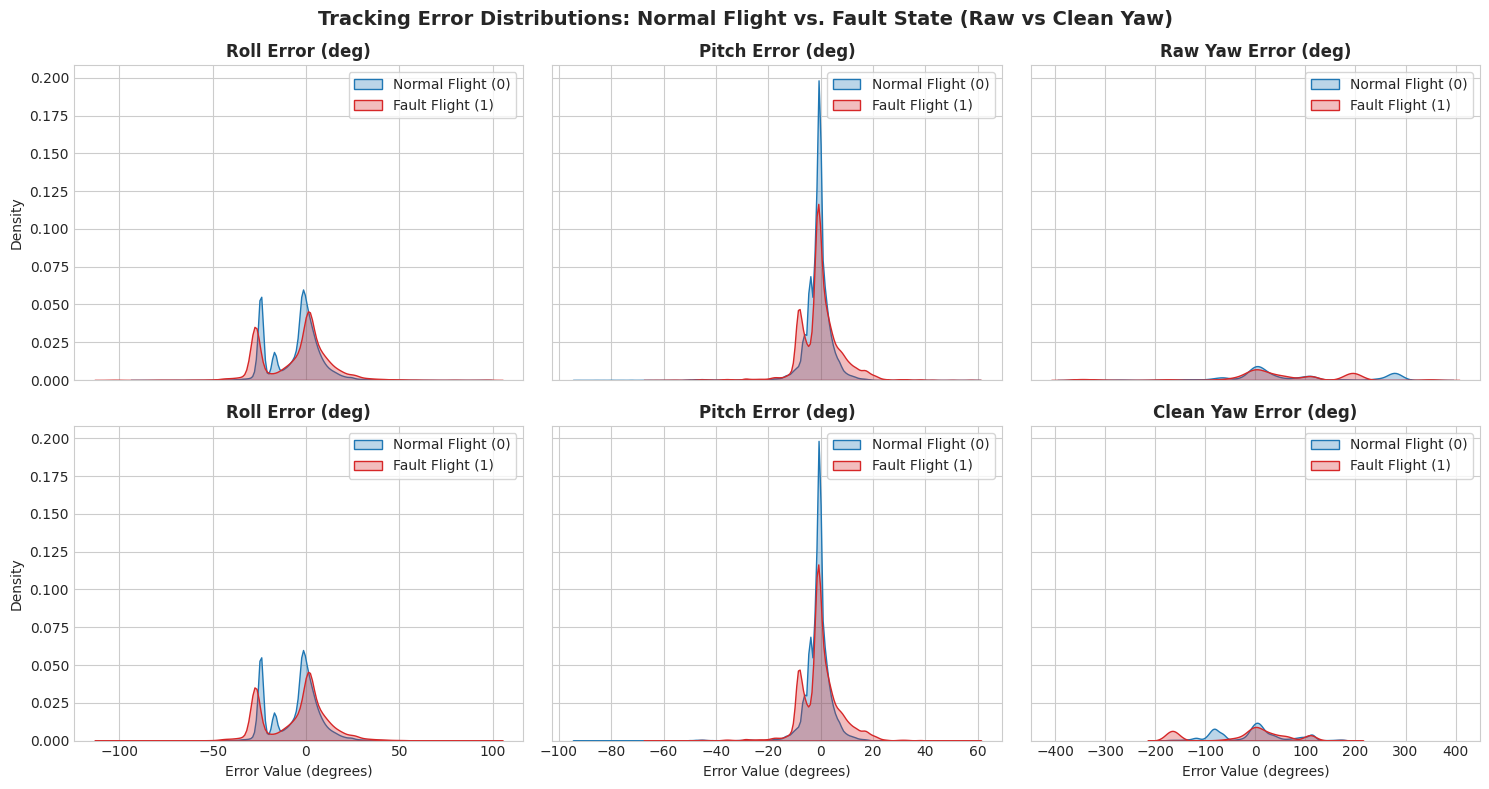

In [33]:
# Helper: Wrap yaw error into [-180, 180] degrees
def wrap_angle_deg(err):
    return (err + 180) % 360 - 180

df['yaw_error_clean'] = wrap_angle_deg(df['yaw_cmd'] - df['yaw_meas'])
# Create a 2-row, 3-column layout to compare raw vs clean yaw
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex='col')
fig.suptitle('Tracking Error Distributions: Normal Flight vs. Fault State (Raw vs Clean Yaw)', 
             fontsize=14, fontweight='bold')

# Row 1: Includes RAW Yaw
row1_cols = [('roll_error', 'Roll Error (deg)', axes[0, 0]),
             ('pitch_error', 'Pitch Error (deg)', axes[0, 1]),
             ('yaw_error', 'Raw Yaw Error (deg)', axes[0, 2])]

# Row 2: Includes CLEAN Yaw
row2_cols = [('roll_error', 'Roll Error (deg)', axes[1, 0]),
             ('pitch_error', 'Pitch Error (deg)', axes[1, 1]),
             ('yaw_error_clean', 'Clean Yaw Error (deg)', axes[1, 2])]

all_cols = row1_cols + row2_cols

for col, title, ax in all_cols:
    sns.kdeplot(data=df[df['binary_fault'] == 0], x=col, ax=ax, label='Normal Flight (0)', 
                color='#1f77b4', fill=True, alpha=0.3, common_norm=False)
    sns.kdeplot(data=df[df['binary_fault'] == 1], x=col, ax=ax, label='Fault Flight (1)', 
                color='#d62728', fill=True, alpha=0.3, common_norm=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Error Value (degrees)')
    ax.set_ylabel('Density')
    ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,180812.0,1.536186e+18,2.552247e+15,1.531931e+18,1.532987e+18,1.536692e+18,1.538765e+18,1.539876e+18
roll_cmd,180812.0,1.085774e-01,2.213079e+01,-4.500000e+01,-2.150250e+01,-9.999999e-02,9.700000e+00,4.499000e+01
roll_meas,180812.0,5.609018e+00,1.767877e+01,-6.645238e+01,-1.070823e+00,1.802363e+00,9.861669e+00,7.128139e+01
roll_error,180812.0,-5.500441e+00,1.441541e+01,-1.062053e+02,-1.728321e+01,-2.406277e+00,2.745284e+00,9.828865e+01
pitch_cmd,180812.0,-6.179695e-01,5.301747e+00,-2.499000e+01,-2.620000e+00,0.000000e+00,1.030000e+00,2.000000e+01
pitch_meas,180812.0,5.292030e-01,6.004527e+00,-5.688078e+01,-1.096565e+00,5.454269e-01,2.054308e+00,7.293653e+01
pitch_error,180812.0,-1.147173e+00,6.450553e+00,-9.304937e+01,-3.104228e+00,-5.996998e-01,1.073058e+00,5.941078e+01
yaw_cmd,180812.0,1.095005e+01,1.038293e+02,-1.790000e+02,-8.200000e+01,0.000000e+00,1.130000e+02,1.800000e+02
yaw_meas,180812.0,-4.744680e+01,9.914901e+01,-1.799952e+02,-1.238708e+02,-8.398824e+01,2.515860e+01,1.799866e+02
yaw_error,180812.0,5.839685e+01,1.326115e+02,-3.587891e+02,-5.047535e+00,1.907950e+01,1.137684e+02,3.589952e+02


In [36]:
output_filename = "uav_fault_dataset_v2.csv"
df.to_csv(output_filename, index=False)
print(f"Successfully processed {len(df)} rows and exported to '{output_filename}'.")

Successfully processed 180812 rows and exported to 'uav_fault_dataset_v2.csv'.
